In [1]:
# Fault Detection using Machine Learning

##  Problem Statement

# The objective of this project is to predict whether a device is operating under normal conditions or experiencing a fault.
#Each device instance contains 47 numerical features (F01–F47), and the target variable `Class` indicates:

#- 0 → Normal
#- 1 → Faulty

# This is a binary classification problem.

In [2]:
## Importing Required Libraries

# We import pandas for data handling and scikit-learn for model training and evaluation.

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [4]:
## Loading the Dataset

# TRAIN.csv contains features and target variable.
# TEST.csv contains features and ID column for prediction.

In [5]:
train = pd.read_csv("TRAIN.csv")
test = pd.read_csv("TEST.csv")

In [6]:
## Class Distribution

# This section checks whether the dataset is balanced or imbalanced.

# Understanding class distribution is important because F1-Score is sensitive to class imbalance.

In [7]:
print(train["Class"].value_counts())

Class
0    26465
1    17311
Name: count, dtype: int64


In [8]:
## Correlation Analysis

# A correlation heatmap is generated to understand relationships between features and support feature analysis.

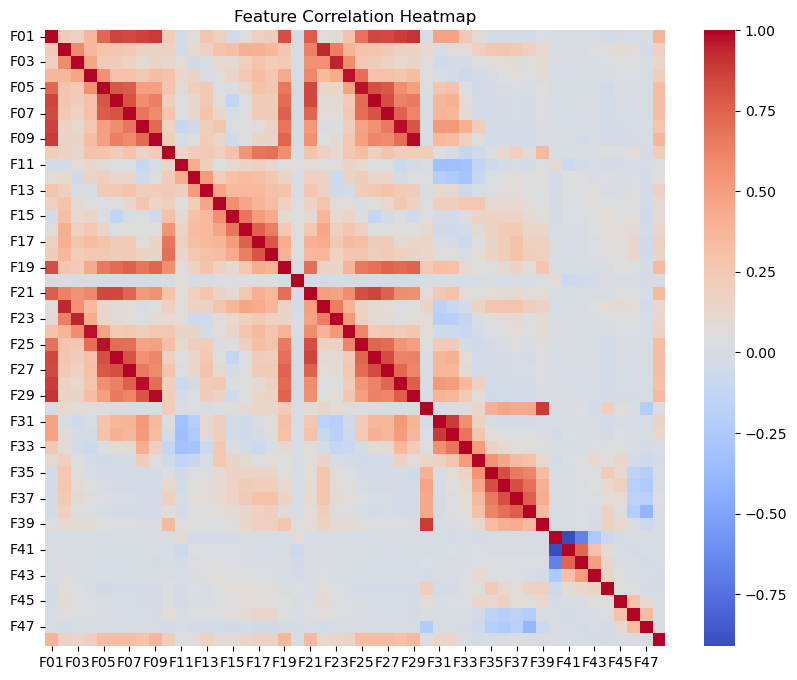

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
## Feature and Target Separation

# - X contains the 47 numerical features.
# - y contains the target variable (Class).
# - X_test is prepared for generating predictions.
# - test_ids are stored for final submission.

In [11]:
## Train-Validation Split

#The dataset is split into 80% training and 20% validation data to evaluate model performance before final training.

In [12]:
X = train.drop("Class", axis=1)
y = train["Class"]

X_test = test.drop("ID", axis=1)
test_ids = test["ID"]

In [13]:
## Model Selection: Random Forest

# Random Forest is chosen because:

# - It handles high-dimensional numerical data effectively.
# - It reduces overfitting using ensemble learning (multiple decision trees).
# - It works well without heavy feature scaling.
# - It is robust to noise and performs well in binary classification tasks.

# Class weight is set to "balanced" to handle potential class imbalance.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("Validation F1-Score:", f1_score(y_val, val_preds))
print("\nClassification Report:\n")

## Model Evaluation

# The model is evaluated using:
# - Accuracy
# - F1-Score (Competition metric)
# - Classification Report

# F1-Score is important because leaderboard ranking is based on it.

print(classification_report(y_val, val_preds))

In [ ]:
final_model = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X, y)
predictions = final_model.predict(X_test)

In [ ]:
## Submission File Creation

# The submission file contains:
# - ID
# - CLASS (Predicted label)

# The file is saved as FINAL.csv in the exact required format.

In [ ]:
submission = pd.DataFrame({
    "ID": test_ids,
    "CLASS": predictions
})

submission.to_csv("FINAL.csv", index=False)

In [ ]:
print(len(submission))

In [ ]:
submission.head()